In [1]:
"""
mo_check_dar_numbers.ipynb

This script is used to check the output of the 120 topic DAR analysis

authors: Roy Oelen

"""

'\nmo_check_dar_numbers.ipynb\n\nThis script is used to check the output of the 120 topic DAR analysis\n\nauthors: Roy Oelen\n\n'

In [2]:
###########
# imports #
###########

# to read our tables
import pandas as pd
# to make the basic plots
import seaborn as sns
import matplotlib.pyplot as plt
# set size of figures
from matplotlib.pyplot import figure
# for making the checksums of exported tables
import hashlib


In [3]:
#############
# functions #
#############


def get_topic_membership_groups(metadata_tbl, topic_columns, metadata_column):
    # we'll save the result for each column
    metrics_per_topic = {}
    # check each topic column
    for topic_column in topic_columns:
        # make the table
        numbers_topic = pd.DataFrame(cell_metadata_with_topic.groupby([metadata_column, topic_column]).size())
        # rename the column to something we can work with
        numbers_topic = numbers_topic.rename({0 : 'nr'}, axis = 1)
        # into a new table
        numbers_topic_df = pd.DataFrame(
            {
                'mtdt_column' : list(numbers_topic.index.get_level_values(metadata_column)), 
                'nr' : numbers_topic['nr'].tolist(), 
                 'in_topic' : list(numbers_topic.index.get_level_values(topic_column)), 
                'topic' : [topic_column] * numbers_topic.shape[0]
            }
        )
        # rename that metadata column to its real name
        numbers_topic_df = numbers_topic_df.rename({'mtdt_column' : metadata_column}, axis = 1)
        # keep only the ones that are associated to the topic
        numbers_topic_df = numbers_topic_df[numbers_topic_df['in_topic'] == True]
        # then drop the in_topic column
        numbers_topic_df = numbers_topic_df.drop(['in_topic'], axis = 1)
        # get the sum of all cells
        cell_numbers_topic_total = numbers_topic_df['nr'].sum()
        # and add the fraction as an additional column
        numbers_topic_df['frac'] = numbers_topic_df['nr'] / cell_numbers_topic_total
        # put into the dictionary
        metrics_per_topic[topic_column] = numbers_topic_df
    # merge all of them
    metrics_all_topics = pd.concat(metrics_per_topic.values())
    return metrics_all_topics
    

def get_color_coding_dict():
    # make the color coding dictionary
    color_coding_dict = {
        "B": "#71BC4B",
        "CD4_T_cells": "#153057",
        "CD4T": "#153057",
        "CD8_T_cells": "#009DDB",
        "CD8T": "#009DDB",
        "Dendritic_cells": "#965EC8",
        "DC": "#965EC8",
        "Endothelial_cells": "#FFFFB3",
        "Fibroblasts": "#386CB0",
        "Glia_cells": "#F0027F",
        "Mast_cells": "#BF5B17",
        "Mature_absorptive_enterocytes": "#A6CEE3",
        "Mature_secretory_enterocytes": "#1B9E77",
        "Memory_B": "#D95F02",
        "Microfold_cell": "#BEAED4",
        "Monocyte": "#EDBA1B",
        "monocyte": "#EDBA1B",
        "Naive_B_cells": "#FDC086",
        "NK": "#E64B50",
        "Plasma_cells": "#DB8E00", 
        "Plasmablast": "#DB8E00", 
        "plasmablast": "#DB8E00",
        "Stem_cells": "#66A61E",
        "Stromal_cells": "#8DD3C7",
        "T_others": "#FF63B6", 
        "T_other": "#FF63B6",
        "Transit_amplifying_cells": "#FF7F00",
        "disconcordant": "gray",
        "CD4+ T cells": "#153057",
        "CD4+ T": "#153057",
        "CD8+ T cells": "#009DDB",
        "CD8+ T": "#009DDB",
        "Dendritic cells": "#965EC8",
        "Endothelial cells": "#FFFFB3",
        "Endothelial\ncells": "#FFFFB3",
        "Fibroblasts": "#386CB0",
        "Glia cells": "#F0027F",
        "MAST cells": "#BF5B17",
        "Mature absorptive enterocytes": "#A6CEE3",
        "Mature\nabsorptive\nenterocytes": "#A6CEE3",
        "Mature secretory enterocytes": "#1B9E77",
        "Mature secretory\nenterocytes": "#1B9E77",
        "Memory B cells": "#D95F02",
        "Microfold cells": "#BEAED4",
        "Monocytes": "#EDBA1B",
        "Naive B cells": "#FDC086",
        "Plasma cells": "#DB8E00",
        "Stem cells": "#66A61E",
        "Stromal cells": "#8DD3C7",
        "other T cells": "#FF63B6",
        "Transit amplifying cells": "#FF7F00",
        "Transit\namplifying cells": "#FF7F00",
        "AI": "darkblue",
        "NI": "darkred",
        "Actively Inflamed": "darkblue",
        "Non-Inflamed": "darkred", 
        "UT": "lightgrey", 
        "24hCA": "forestgreen"
    }

    # # Whitening percentage
    # pct_whitening = 40

    # # Add up and down regulation colors
    # cell_types = color_coding_dict.keys()
    # for cell_type in cell_types:
    #     color_coding_dict[f"{cell_type} up"] = color_coding_dict[cell_type]
    #     color_coding_dict[f"{cell_type} down"] = plt.cm.colors.to_hex(plt.cm.colors.rgb_to_hsv(plt.cm.colors.hex2color(color_coding_dict[cell_type])) * (1 - pct_whitening / 100))

    return color_coding_dict


# method to create md5
def create_md5_file(input_file):
    """
    Creates an MD5 hash of the specified file and writes it to a new file with the same name but .md5 added to the extension.

    Args:
        input_file (str): The path to the input file for which the MD5 hash should be created.

    Returns:
        int: Returns 0 on success, 1 on failure.

    Raises:
        FileNotFoundError: Thrown if the input file does not exist.
        IOError: Thrown if there is an error reading the input file (like permission denied) or writing the output md5 file.
    """
    try:
        # get an md5 of the file
        digest = None
        with open(input_file, "rb") as f:
            # try Python 3.11+ method if it is available
            if callable(getattr(hashlib, 'file_digest', None)):
                # digest with one command
                digest = hashlib.file_digest(f, 'md5')
            # or the older 3.8+ method if we don't have the newer method
            else:
                # initialize digest
                digest = hashlib.md5()
                # read file in chunks
                while chunk := f.read(8192):
                    # update digestion
                    digest.update(chunk)       
        # get the output path of the md5
        output_md5_loc = ''.join([input_file, '.md5'])
        # and write that
        with open(output_md5_loc, "w") as m:
            m.write(digest.hexdigest())
        # upon success, return 0
        return 0
    except Exception as e:
        print(f"Exception occured upon md5 file creation: {e}")
        return 1



In [4]:
##############
# file paths #
##############

# location of topic membership
topic_memberships_cells_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/models/all_nuclei_and_regions_major_minor//mo_topic_cell_membership_120.tsv.gz'

# location of topic membership
topic_memberships_regions_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/models/all_nuclei_and_regions_major_minor//mo_topic_region_membership_120.tsv.gz'

# location of topic metrics
topic_metrics_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/models/all_nuclei_and_regions_major_minor//mo_topic_metrics_120.tsv.gz'

# location of the cell metadata
cell_metadata_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/deconstruced_atac_objects/merged_major_and_minor_celltypes/metadata.tsv.gz'

# location of the region metadata
region_metadata_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/deconstruced_atac_objects/merged_major_and_minor_celltypes/region_annotations.tsv.gz'

# location of specific cell types
highres_condition_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/cell_type_assignment/azimuth/10x_multiome_PBMCs/mo_azimuth_ct_10xmultiome.tsv'

# location of the dars
dars_table_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/merged_major_and_minor_celltypes_120topics_dars.tsv.gz'


In [5]:
##############
# read files #
##############

# read all the files
dars_table = pd.read_csv(dars_table_loc, sep = '\t', header = 0)
topic_memberships_cells = pd.read_csv(topic_memberships_cells_loc, sep = '\t', header = 0)
topic_memberships_regions = pd.read_csv(topic_memberships_regions_loc, sep = '\t', header = 0)
topic_metrics = pd.read_csv(topic_metrics_loc, sep = '\t', header = 0)
cell_metadata = pd.read_csv(cell_metadata_loc, sep = '\t', header = 0)
region_metadata = pd.read_csv(region_metadata_loc, sep = '\t', header = 0)
highres_condition = pd.read_csv(highres_condition_loc, sep = '\t', header = 0)


In [6]:
##############################
# filter to significant DARs #
##############################

# just subset to the significant ones (even though that is not necessary)
dars_table = dars_table[dars_table['Adjusted_pval'] < 0.05]


In [7]:
############################
# DAR and topic statistics #
############################

# get the number of DARs per topic
dars_per_topic = pd.DataFrame(dars_table['Contrast'].value_counts())
# get the number of DARs per region
dars_per_region = pd.DataFrame(dars_table['region'].value_counts())
# add the topic as explicit column in the dars per topic
dars_per_topic['Topic'] = dars_per_topic.index
# and rename 'Contrast'
dars_per_topic = dars_per_topic.rename({'Contrast' : 'n_dar'}, axis = 1)
# and repeat for the region one as well
dars_per_region = dars_per_region.rename({'region' : 'n_topic'}, axis = 1)
dars_per_region['region'] = dars_per_region.index


In [8]:
# count the number of regions associated per topic
topic_region_counts = pd.DataFrame(topic_memberships_regions.drop('region', axis=1).sum(axis=0))
topic_region_counts = topic_region_counts.rename({0 : 'n_region_members'}, axis = 1)


In [9]:
# add the topic explicitly to the topic metrics
topic_metrics['Topic_nr'] = range(1, 121, 1)
# as string as well
topic_metrics[['Topic']] = 'Topic' + topic_metrics[['Topic_nr']].astype(str)
# and set that as the index
topic_metrics.index = topic_metrics['Topic']


In [10]:
# set the index for the dars per topic as well
dars_per_topic.index = dars_per_topic['Topic']
# add those number of dars to the topic metrics
topic_metrics = pd.concat([topic_metrics, dars_per_topic.drop(['Topic'], axis = 1)], axis = 1)
topic_metrics

,Log10_Assignments,Assignments,Regions_in_binarized_topic,Cells_in_binarized_topic,Coherence,Marginal_topic_dist,Gini_index,Topic_nr,Topic,n_dar
Topic,,,,,,,,,,
Topic1,7.878954,75675350.0,7248,35845,-0.861188,0.015014,0.849930,1,Topic1,80192.0
Topic2,7.568723,37044459.0,14120,2770,-1.821028,0.007379,0.870388,2,Topic2,87681.0
Topic3,7.537614,34483685.0,30006,24901,-0.355008,0.006861,0.716479,3,Topic3,39498.0
Topic4,7.748453,56034153.0,5039,17403,-1.370604,0.011122,0.926869,4,Topic4,51064.0
Topic5,7.591762,39062632.0,17059,55094,-1.144399,0.007772,0.678712,5,Topic5,39053.0
...,...,...,...,...,...,...,...,...,...,...
Topic116,7.869655,74072164.0,11257,15657,-1.567376,0.014700,0.917220,116,Topic116,82347.0
Topic117,7.899063,79261588.0,9970,35892,-1.561511,0.015730,0.883559,117,Topic117,92422.0
Topic118,7.432436,27066717.0,8156,4613,-1.948965,0.005398,0.883863,118,Topic118,53033.0


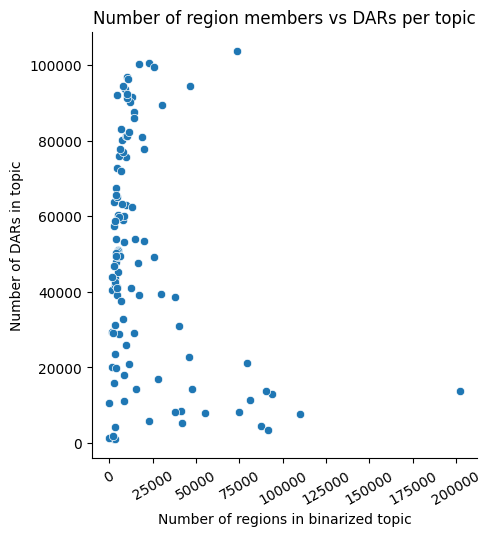

In [11]:
#######################
# DAR and topic plots #
#######################

# and plot the rank vs the number of DARs
ax = sns.relplot(data = topic_metrics, x = "Regions_in_binarized_topic", y = "n_dar")
# with nicer labels
ax.set(xlabel='Number of regions in binarized topic', ylabel='Number of DARs in topic', title = 'Number of region members vs DARs per topic')
# rotate label because it is long
plt.xticks(rotation=30)
plt.show()


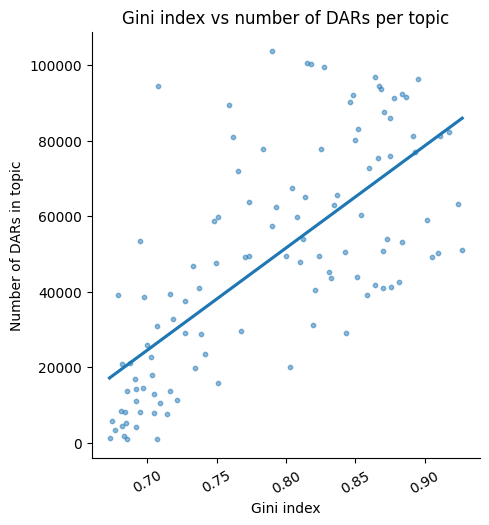

In [12]:
# and plot the rank vs the number of DARs
#ax = sns.relplot(data = topic_metrics, x = "Gini_index", y = "n_dar")
ax = sns.lmplot(data=topic_metrics, x='Gini_index', y='n_dar', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
# with nicer labels
ax.set(xlabel='Gini index', ylabel='Number of DARs in topic', title = 'Gini index vs number of DARs per topic')
# rotate label because it is long
plt.xticks(rotation=30)
plt.show()


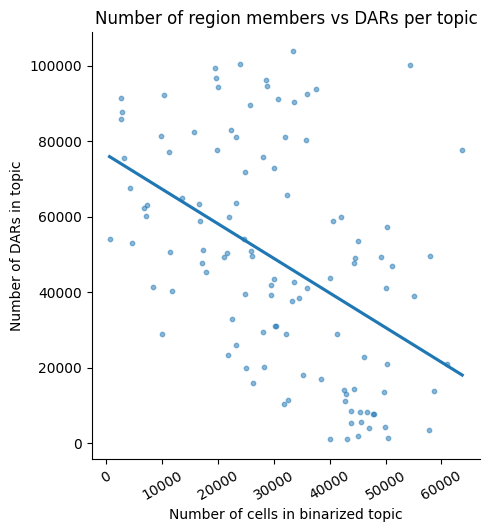

In [13]:
# and plot the rank vs the number of DARs
#ax = sns.relplot(data = topic_metrics, x = "Gini_index", y = "n_dar")
ax = sns.lmplot(data=topic_metrics, x='Cells_in_binarized_topic', y='n_dar', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
# with nicer labels
ax.set(xlabel='Number of cells in binarized topic', ylabel='Number of DARs in topic', title = 'Number of region members vs DARs per topic')
# rotate label because it is long
plt.xticks(rotation=30)
plt.show()


In [14]:
# set the index for both the metadata and the topic membership of the cells
topic_memberships_cells.index = topic_memberships_cells['barcode_lane']
cell_metadata.index = cell_metadata['bc']
# merge these together
cell_metadata_with_topic = pd.concat([cell_metadata, topic_memberships_cells.drop(['barcode_lane'] , axis = 1)], axis = 1)
# check how it looks
cell_metadata_with_topic

,bc,orig.ident,nCount_peaks,nFeature_peaks,lane,barcode,best_match_sample,second_match_sample,best_match_correlation,second_match_correlation,...,Topic111,Topic112,Topic113,Topic114,Topic115,Topic116,Topic117,Topic118,Topic119,Topic120
ATTCATGAGGCTGTCA_230105_lane1,ATTCATGAGGCTGTCA_230105_lane1,wijst_multiome,29915,20759,230105_lane1,ATTCATGAGGCTGTCA,MO204,MO206-2,0.782384,0.324441,...,False,False,False,False,False,False,False,False,False,False
AGTGGACAGCAAGACA_230105_lane1,AGTGGACAGCAAGACA_230105_lane1,wijst_multiome,28294,18170,230105_lane1,AGTGGACAGCAAGACA,UGLI012768,UGLI009726,0.796304,0.333029,...,False,False,False,False,False,False,False,False,False,False
CCAACCCGTATGGTGC_230105_lane1,CCAACCCGTATGGTGC_230105_lane1,wijst_multiome,29584,19436,230105_lane1,CCAACCCGTATGGTGC,MO205,MO903,0.778065,0.333788,...,False,False,False,False,False,False,False,False,False,False
TCCTAGTGTTTAACGG_230105_lane1,TCCTAGTGTTTAACGG_230105_lane1,wijst_multiome,26175,19902,230105_lane1,TCCTAGTGTTTAACGG,UGLI011032,MO306,0.791207,0.330940,...,False,False,False,False,False,False,False,False,False,False
AGGTTTGGTGTGAGAG_230105_lane1,AGGTTTGGTGTGAGAG_230105_lane1,wijst_multiome,26110,19858,230105_lane1,AGGTTTGGTGTGAGAG,UGLI021599,MO146,0.773680,0.333205,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAGTGAGGTTATCCTA_230316_lane7,GAGTGAGGTTATCCTA_230316_lane7,wijst_multiome,3140,2909,230316_lane7,GAGTGAGGTTATCCTA,MO215,MO65,0.787710,0.322271,...,True,False,False,False,False,False,False,False,False,False
GTACCGGGTACTGATG_230316_lane7,GTACCGGGTACTGATG_230316_lane7,wijst_multiome,3140,2958,230316_lane7,GTACCGGGTACTGATG,MO214,MO1108,0.783397,0.330568,...,False,False,False,False,False,False,False,False,False,False
TTGGTGAGTTAGTTGG_230316_lane7,TTGGTGAGTTAGTTGG_230316_lane7,wijst_multiome,3181,2669,230316_lane7,TTGGTGAGTTAGTTGG,MO215,MO65,0.787710,0.322271,...,True,False,True,False,False,False,False,False,False,False
AGAGGATGTCTAGCTT_230316_lane7,AGAGGATGTCTAGCTT_230316_lane7,wijst_multiome,2999,2822,230316_lane7,AGAGGATGTCTAGCTT,MO215,MO65,0.787710,0.322271,...,False,False,True,False,False,False,False,False,False,False


In [15]:
# get the unique topics
topics_present = dars_per_topic['Topic'].unique().tolist()
# and get the memberships for the lanes
lane_topic_memberships = get_topic_membership_groups(cell_metadata_with_topic, topics_present, 'lane')
# for the samples
sample_topic_memberships = get_topic_membership_groups(cell_metadata_with_topic, topics_present, 'sample_final')
# condition as well
condition_topic_memberships = get_topic_membership_groups(cell_metadata_with_topic, topics_present, 'inflammation_final')
# cell type as well
celltype_topic_memberships = get_topic_membership_groups(cell_metadata_with_topic, topics_present, 'cell_type')


In [16]:
# save the membership tables
lane_topic_membership_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/topic_memberships/region_memberships/membership_tables/mo_topic_membership_lanes.tsv.gz'
sample_topic_membership_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/topic_memberships/region_memberships/membership_tables/mo_topic_membership_samples.tsv.gz'
condition_topic_membership_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/topic_memberships/region_memberships/membership_tables/mo_topic_membership_conditions.tsv.gz'
celltype_topic_membership_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/topic_memberships/region_memberships/membership_tables/mo_topic_membership_celltypes.tsv.gz'
# to files
lane_topic_memberships.to_csv(path_or_buf = lane_topic_membership_loc, sep = '\t', header = True, index = False, compression = 'gzip')
sample_topic_memberships.to_csv(path_or_buf = sample_topic_membership_loc, sep = '\t', header = True, index = False, compression = 'gzip')
condition_topic_memberships.to_csv(path_or_buf = condition_topic_membership_loc, sep = '\t', header = True, index = False, compression = 'gzip')
celltype_topic_memberships.to_csv(path_or_buf = celltype_topic_membership_loc, sep = '\t', header = True, index = False, compression = 'gzip')
# and make checksums
create_md5_file(lane_topic_membership_loc)
create_md5_file(sample_topic_membership_loc)
create_md5_file(condition_topic_membership_loc)
create_md5_file(celltype_topic_membership_loc)

0

<Figure size 2000x1600 with 0 Axes>

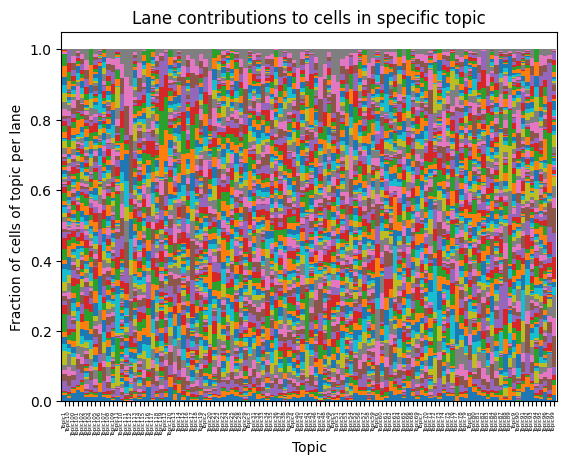

In [17]:
# pivat the table so it is plot compatible
lane_topic_memberships_pivoted = lane_topic_memberships.pivot(index='topic', columns='lane', values='frac')
# set the size for the plot
plt.figure(figsize=(20, 16))
# make the initial plot
ax = lane_topic_memberships_pivoted.plot(kind='bar', stacked=True, width = 1)
# add the topic as x label
plt.xlabel('Topic')
# and the fraction as y label
plt.ylabel('Fraction of cells of topic per lane')
plt.title('Lane contributions to cells in specific topic')
# decrease font size for the  ticks
ax.tick_params(axis='x', which='major', labelsize=4)
# rotate label because it is long
plt.xticks(rotation=90)
# remove legend, because it is unreadable here
ax.legend().set_visible(False)
# and save the plot
plt.savefig('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/plots/mo_120_topics_to_lane_membership.pdf', dpi=300, bbox_inches='tight')
# show the plot
plt.show()


<Figure size 2000x1600 with 0 Axes>

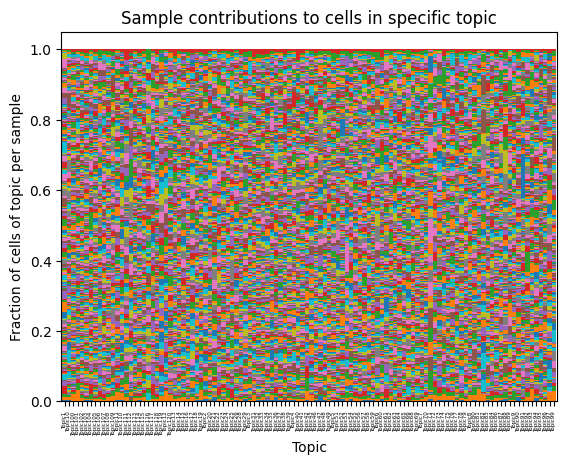

In [18]:
# pivat the table so it is plot compatible
sample_topic_memberships_pivoted = sample_topic_memberships.pivot(index='topic', columns='sample_final', values='frac')
# set the size for the plot
plt.figure(figsize=(20, 16))
# make the initial plot
ax = sample_topic_memberships_pivoted.plot(kind='bar', stacked=True, width = 1)
# add the topic as x label
plt.xlabel('Topic')
# and the fraction as y label
plt.ylabel('Fraction of cells of topic per sample')
plt.title('Sample contributions to cells in specific topic')
# decrease font size for the  ticks
ax.tick_params(axis='x', which='major', labelsize=4)
# rotate label because it is long
plt.xticks(rotation=90)
# remove legend, because it is unreadable here
ax.legend().set_visible(False)
# and save the plot
plt.savefig('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/plots/mo_120_topics_to_sample_membership.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()


<Figure size 2000x1600 with 0 Axes>

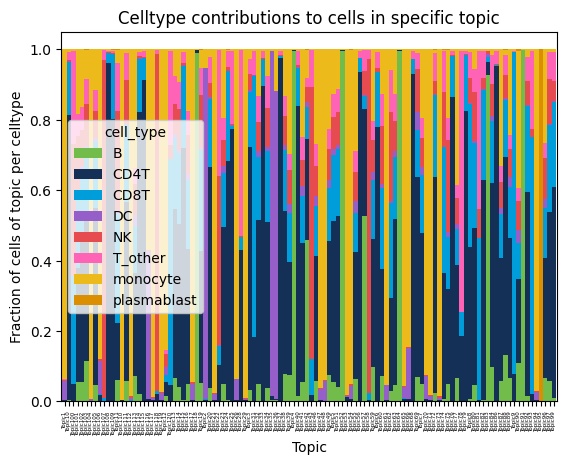

In [19]:
# get the colour codes for the cell types
cell_type_colours = get_color_coding_dict()
# pivat the table so it is plot compatible
celltype_topic_memberships_pivoted = celltype_topic_memberships.pivot(index='topic', columns='cell_type', values='frac')
# set the size for the plot
plt.figure(figsize=(20, 16))
# make the initial plot
ax = celltype_topic_memberships_pivoted.plot(kind='bar', stacked=True, width = 1, color=[cell_type_colours[col] for col in celltype_topic_memberships_pivoted.columns])
# add the topic as x label
plt.xlabel('Topic')
# and the fraction as y label
plt.ylabel('Fraction of cells of topic per celltype')
plt.title('Celltype contributions to cells in specific topic')
# decrease font size for the  ticks
ax.tick_params(axis='x', which='major', labelsize=4)
# rotate label because it is long
plt.xticks(rotation=90)
# and save the plot
plt.savefig('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/plots/mo_120_topics_to_celltype_membership.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()


<Figure size 2000x1600 with 0 Axes>

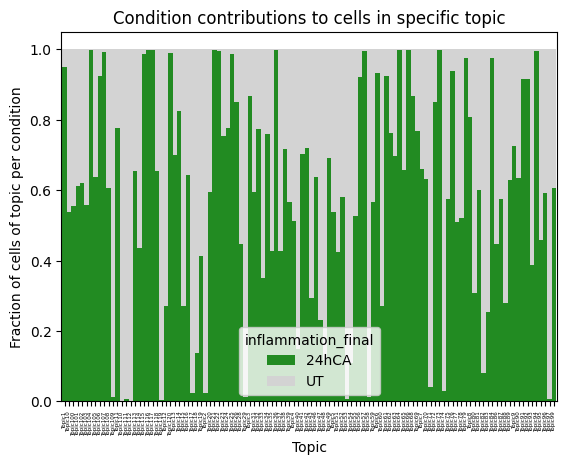

In [20]:
# get the colour codes for the cell types
condition_colours = get_color_coding_dict()
# pivat the table so it is plot compatible
condition_topic_memberships_pivoted = condition_topic_memberships.pivot(index='topic', columns='inflammation_final', values='frac')
# set the size for the plot
plt.figure(figsize=(20, 16))
# make the initial plot
ax = condition_topic_memberships_pivoted.plot(kind='bar', stacked=True, width = 1, color=[condition_colours[col] for col in condition_topic_memberships_pivoted.columns])
# add the topic as x label
plt.xlabel('Topic')
# and the fraction as y label
plt.ylabel('Fraction of cells of topic per condition')
plt.title('Condition contributions to cells in specific topic')
# decrease font size for the  ticks
ax.tick_params(axis='x', which='major', labelsize=4)
# rotate label because it is long
plt.xticks(rotation=90)
# and save the plot
plt.savefig('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/plots/mo_120_topics_to_condition_membership.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()


In [21]:
# add new column to show the long covid status
cell_metadata_with_topic['LONG CoVID status'] = cell_metadata_with_topic['condition_final'].astype(str) + ', ' + cell_metadata_with_topic['LONG_COVID_final'].astype(str) + ', ' + cell_metadata_with_topic['LONG_COVID_method'].astype(str)
# the stimulations were always controls
cell_metadata_with_topic['LONG CoVID status'] = cell_metadata_with_topic['LONG CoVID status'].replace('24hCA.*', '24hCA', regex = True)
# make a table describing that
longcovid_topic_memberships = get_topic_membership_groups(cell_metadata_with_topic, topics_present, 'LONG CoVID status')


<Figure size 2000x1600 with 0 Axes>

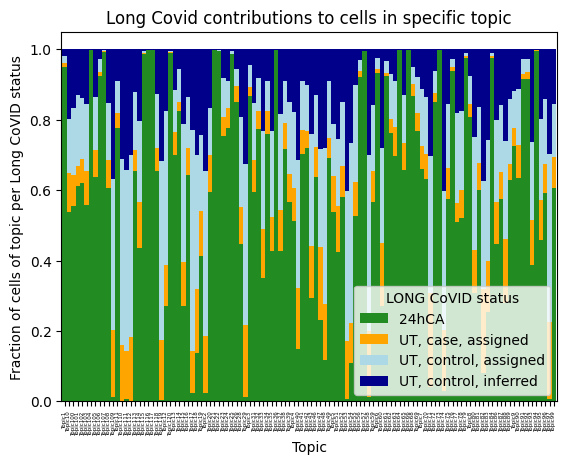

In [22]:
# pivat the table so it is plot compatible
longcovid_topic_memberships_pivoted = longcovid_topic_memberships.pivot(index='topic', columns='LONG CoVID status', values='frac')
# set the size for the plot
plt.figure(figsize=(20, 16))
# make the initial plot
ax = longcovid_topic_memberships_pivoted.plot(kind='bar', stacked=True, width = 1, color=['forestgreen', 'orange', 'lightblue', 'darkblue'])
# add the topic as x label
plt.xlabel('Topic')
# and the fraction as y label
plt.ylabel('Fraction of cells of topic per Long CoVID status')
plt.title('Long Covid contributions to cells in specific topic')
# decrease font size for the  ticks
ax.tick_params(axis='x', which='major', labelsize=4)
# rotate label because it is long
plt.xticks(rotation=90)
# remove legend, because it is unreadable here
#ax.legend().set_visible(False)
# and save the plot
plt.savefig('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/plots/mo_120_topics_to_longcovid_membership.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()